# NBA Scrapper using py_ball

In [1]:
%pip install nba_api pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install numpy==1.23.5 --force-reinstall
%pip install matplotlib --force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 4.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nba-api 1.9.0 requires numpy>=1.26.0; python_version < "3.13", but you have numpy 1.23.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.6 MB)
  Using cached kiwisolver-1.4.8-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl (4.6 MB)
  Using cached packa

In [6]:
from nba_api.stats.static import teams
import pandas as pd
from datetime import datetime, timedelta
from config import *
from utils import *
import time

#today formated as YYYY-MM-DD
today = datetime.today().strftime('%Y-%m-%d')
today_precise = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')

## Fetch Players data

In [7]:
import pandas as pd
from nba_api.stats.static import players
import os


all_boxscores_files = [
    os.path.join(DATA_BOXSCORES_DIR, f) for f in os.listdir(DATA_BOXSCORES_DIR) if f.endswith('.csv')
]
dfs = [pd.read_csv(f, low_memory=False) for f in all_boxscores_files]
boxscores_df = pd.concat(dfs, ignore_index=True)
player_ids_seen = set(boxscores_df['PLAYER_ID'].dropna().astype(int).unique())

# 2. Get all NBA players (historical and active)
nba_players = players.get_players()
nba_players_df = pd.DataFrame(nba_players)
nba_players_df['id'] = nba_players_df['id'].astype(int)

# 3. Add flag: has this player been seen in your dataset?
nba_players_df['in_boxscore'] = nba_players_df['id'].isin(player_ids_seen)

# (Optionnel) Add "nb_appearances" (number of games in boxscores for each player)
counts = boxscores_df['PLAYER_ID'].value_counts().astype(int)
nba_players_df['nb_appearances'] = nba_players_df['id'].map(counts).fillna(0).astype(int)

# 4. Save the complete master file
#nba_players_df.to_csv(os.path.join(DATA_PLAYERS_DIR, 'players_master.csv'), index=False)

save_dataframe_to_csv(nba_players_df, DATA_PLAYERS_DIR, prefix='players_master_', suffix=today_precise)

print("✅ Players master file saved with historicals and seen flags!")


✅ Players master file saved with historicals and seen flags!


## Quick visualization

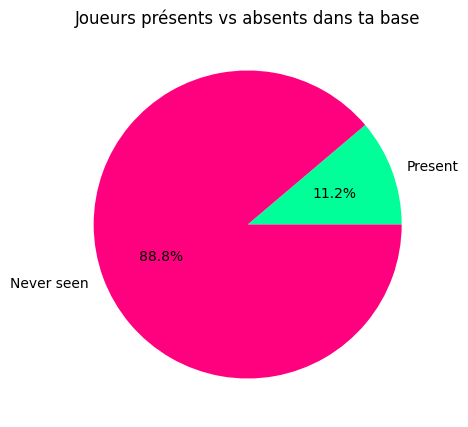

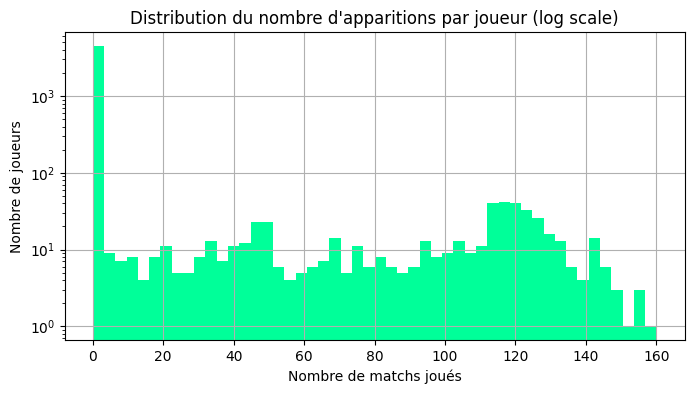

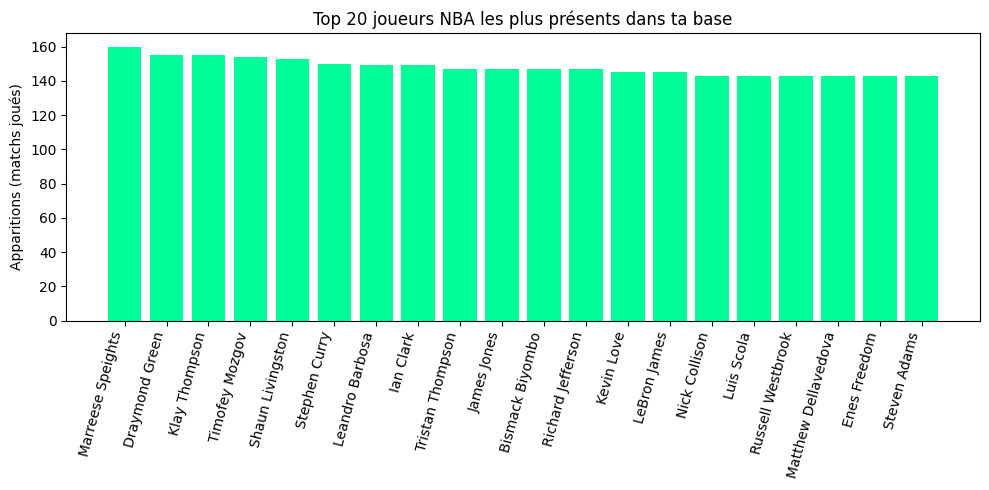

4462 joueurs historiques jamais vus dans tes boxscores !


,id,full_name,first_name,last_name,is_active,in_boxscore,nb_appearances
4575,78419,Gary Voce,Gary,Voce,False,False,0
2923,77529,Mel McGaha,Mel,McGaha,False,False,0
1748,76920,Bruce Hale,Bruce,Hale,False,False,0
1077,76555,George Dempsey,George,Dempsey,False,False,0
3656,1821,Mark Randall,Mark,Randall,False,False,0
1826,76958,Chris Harris,Chris,Harris,False,False,0
2081,2212,Steven Hunter,Steven,Hunter,False,False,0
1907,971,Mark Hendrickson,Mark,Hendrickson,False,False,0
2685,1627848,Shawn Long,Shawn,Long,False,False,0
2294,279,Charles Jones,Charles,Jones,False,False,0


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Charge ton master file
players_master = pd.read_csv(get_latest_file(DATA_PLAYERS_DIR))

# 1. Combien de joueurs présents vs absents dans tes datas
present = players_master['in_boxscore'].sum()
total = len(players_master)
absents = total - present

plt.figure(figsize=(5, 5))
plt.pie([present, absents], labels=['Present', 'Never seen'], autopct='%1.1f%%', colors=['#00FF99', '#FF007F'])
plt.title("Joueurs présents vs absents dans ta base")
plt.show()

# 2. Distribution du nombre d'apparitions (log pour voir les extrêmes)
plt.figure(figsize=(8, 4))
players_master['nb_appearances'].hist(bins=50, log=True, color='#00FF99')
plt.title("Distribution du nombre d'apparitions par joueur (log scale)")
plt.xlabel("Nombre de matchs joués")
plt.ylabel("Nombre de joueurs")
plt.show()

# 3. Top 20 joueurs les plus présents
top20 = players_master.sort_values('nb_appearances', ascending=False).head(20)
plt.figure(figsize=(10, 5))
plt.bar(top20['full_name'], top20['nb_appearances'], color='#00FF99')
plt.title("Top 20 joueurs NBA les plus présents dans ta base")
plt.xticks(rotation=75, ha='right')
plt.ylabel("Apparitions (matchs joués)")
plt.tight_layout()
plt.show()

# 4. Pour le fun : joueurs jamais vus (curiosité)
never_seen = players_master[~players_master['in_boxscore']]
print(f"{len(never_seen)} joueurs historiques jamais vus dans tes boxscores !")
display(never_seen.sample(10))
